## Анализ поведения пользователей e-commerce и сегментация клиентской базы с использованием RFM и когортного анализа для выявления драйверов выручки и удержания.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

df = pd.read_csv('online_retail_II.csv')

### Для упрощения анализа рассматриваются только завершённые покупки. Возвратные и некорректные транзакции исключены из выборки.

In [27]:
df = df.rename({'Customer ID' : 'Customer_ID'}, axis=1)
df_clean = df.copy()

df_clean = df_clean.dropna(subset=['Customer_ID'])

df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
df_clean.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [45]:
len(df_clean["Customer_ID"].unique()) # 5878 - кол-во уникальных пользователей
len(df_clean["Invoice"].unique()) # общее число заказов 36969
df_clean['revenue'] = df_clean["Quantity"] * df_clean["Price"]

df_orders = df_clean.groupby("Invoice", as_index=False)["revenue"].sum()

df_orders["revenue"].mean() # 479.9542637885796

df_customers = df_clean.groupby("Customer_ID", as_index=False)["revenue"].sum()
df_customers.sort_values("revenue", ascending=False).head(10) # Top клиентов

# df_customers["revenue"].sort_values(ascending=False).cumsum() / df_customers["revenue"].sum() # не понял вообще что тут вывело 

df_clean.groupby("Customer_ID")["Invoice"].nunique().describe() # тоже не понял что это вообще

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

### сохранение


In [46]:
df_customers.to_csv("customers_rfm_base.csv", index=False)
df_orders.to_csv("orders_revenue.csv", index=False)

## RFM-анализ + когорты/retention

In [ ]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
snapshot_date = df_clean['InvoiceDate'].max() 
df_clean.groupby("Customer_ID")["revenue"].sum()

last_purchase = df_clean.groupby("Customer_ID")["InvoiceDate"].max()
recency = snapshot_date - last_purchase
frequency = df_clean.groupby("Customer_ID")["Invoice"].nunique()
monetary = df_clean.groupby("Customer_ID")["revenue"].sum()

rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})



In [ ]:

rfm["R_score"] = pd.cut(rfm["Recency"],
                        bins=[0, 30, 90, 9999],
                        labels=["good", "medium", "bad"])
rfm["F_score"] = pd.cut(rfm["Frequency"],
                        bins=[0, 2, 6, 9999],
                        labels=["low", "medium", "high"])
rfm["M_score"] = pd.cut(rfm["Monetary"],
                        bins=[0, 100, 500, 999999],
                        labels=["low", "medium", "high"])

rfm["Segment"] = rfm["R_score"].astype(str) + "_" + \
                 rfm["F_score"].astype(str) + "_" + \
                 rfm["M_score"].astype(str)
                 
            
def segment(row):
    if row["Recency"] <= 30 and row["Frequency"] >= 5:
        return "VIP"
    elif row["Frequency"] >= 3:
        return "Loyal"
    elif row["Recency"] > 90:
        return "Lost"
    else:
        return "At Risk"

rfm["Segment"] = rfm.apply(segment, axis=1)


rfm["Segment"].value_counts()
# Segment
# Loyal      2220
# Lost       1865
# VIP        1091
# At Risk     702


rfm.groupby("Segment")["Monetary"].sum()

# Segment
# At Risk    5.408919e+05
# Lost       8.503197e+05
# Loyal      5.641918e+06
# VIP        1.071030e+07

Segment
At Risk    5.408919e+05
Lost       8.503197e+05
Loyal      5.641918e+06
VIP        1.071030e+07
Name: Monetary, dtype: float64

In [78]:
rfm.to_csv("rfm_segments.csv", index=False)

### Графики

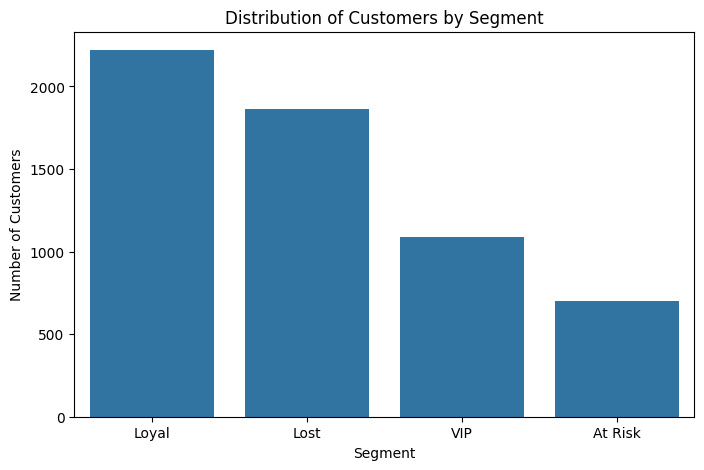

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(data=rfm, x="Segment", order=rfm["Segment"].value_counts().index)

plt.title("Distribution of Customers by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show() # Распределение клиентов по сегментам (COUNT)

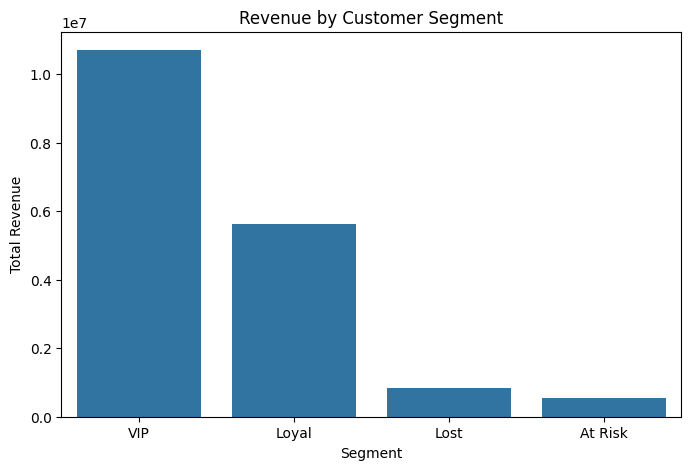

In [ ]:
plt.figure(figsize=(8,5))

seg_revenue = rfm.groupby("Segment")["Monetary"].sum().reset_index()

sns.barplot(data=seg_revenue, x="Segment", y="Monetary",
            order=seg_revenue.sort_values("Monetary", ascending=False)["Segment"])

plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.show() # Выручка по сегментам (САМЫЙ важный график)

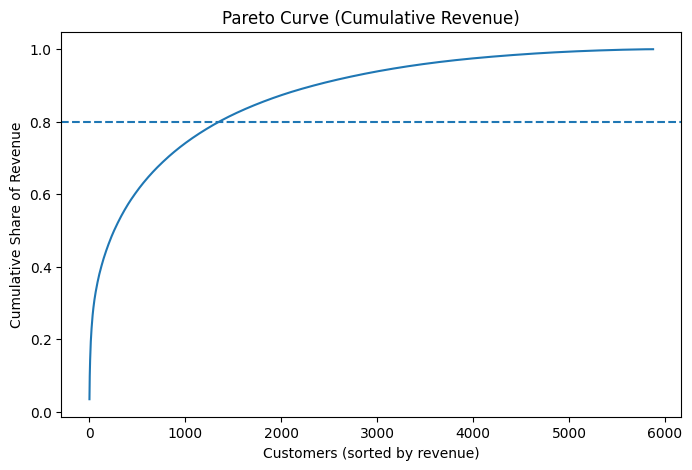

In [81]:
import numpy as np

df_pareto = rfm.sort_values("Monetary", ascending=False).copy()
df_pareto["cum_revenue"] = df_pareto["Monetary"].cumsum()
df_pareto["cum_percent"] = df_pareto["cum_revenue"] / df_pareto["Monetary"].sum()

plt.figure(figsize=(8,5))

sns.lineplot(x=np.arange(len(df_pareto)), y=df_pareto["cum_percent"])

plt.title("Pareto Curve (Cumulative Revenue)")
plt.xlabel("Customers (sorted by revenue)")
plt.ylabel("Cumulative Share of Revenue")

plt.axhline(0.8, linestyle="--")

plt.show()

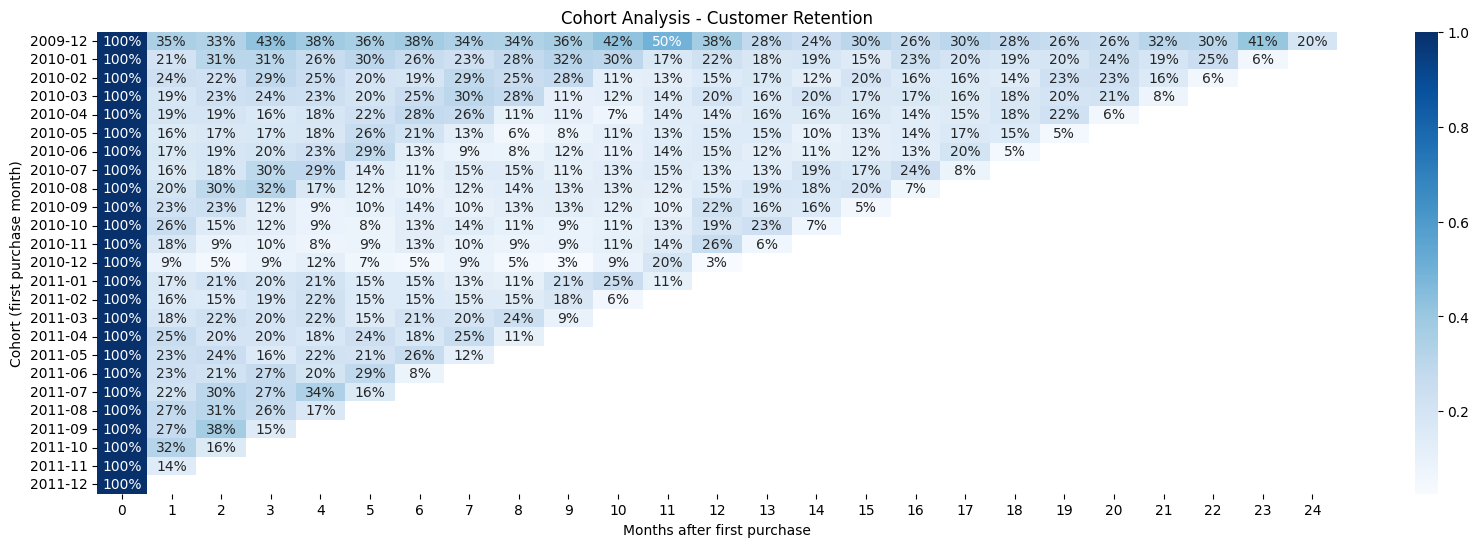

In [90]:
from operator import attrgetter
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["order_month"] = df_clean["InvoiceDate"].dt.to_period("M")

df_clean["cohort"] = df_clean.groupby("Customer_ID")["InvoiceDate"].transform("min").dt.to_period("M")

df_clean["cohort_index"] = (
    (df_clean["order_month"] - df_clean["cohort"])
    .apply(attrgetter("n"))
)
df_clean["cohort_index"] = (
    (df_clean["order_month"].astype(int) - df_clean["cohort"].astype(int))
)
cohort_data = df_clean.groupby(["cohort", "cohort_index"])["Customer_ID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(
    index="cohort",
    columns="cohort_index",
    values="Customer_ID"
)

cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,6))


sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")

plt.title("Cohort Analysis - Customer Retention")
plt.xlabel("Months after first purchase")
plt.ylabel("Cohort (first purchase month)")

plt.show()